In [2]:
from pathlib import Path

DATA_DIR = Path("../data/plantvillage/source/raw/color")
print("Dataset :", DATA_DIR.resolve())
print("Existe :", DATA_DIR.exists())

Dataset : /home/kaba/formation-alternance/projet-fil-rouge/sini/data/plantvillage/source/raw/color
Existe : True


In [3]:
classes = [p.name for p in DATA_DIR.iterdir() if p.is_dir()]

print("Nombre de classes :", len(classes))
print("\nClasses :")
for classe in sorted(classes):
    print("-", classe)

Nombre de classes : 38

Classes :
- Apple___Apple_scab
- Apple___Black_rot
- Apple___Cedar_apple_rust
- Apple___healthy
- Blueberry___healthy
- Cherry_(including_sour)___Powdery_mildew
- Cherry_(including_sour)___healthy
- Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
- Corn_(maize)___Common_rust_
- Corn_(maize)___Northern_Leaf_Blight
- Corn_(maize)___healthy
- Grape___Black_rot
- Grape___Esca_(Black_Measles)
- Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
- Grape___healthy
- Orange___Haunglongbing_(Citrus_greening)
- Peach___Bacterial_spot
- Peach___healthy
- Pepper,_bell___Bacterial_spot
- Pepper,_bell___healthy
- Potato___Early_blight
- Potato___Late_blight
- Potato___healthy
- Raspberry___healthy
- Soybean___healthy
- Squash___Powdery_mildew
- Strawberry___Leaf_scorch
- Strawberry___healthy
- Tomato___Bacterial_spot
- Tomato___Early_blight
- Tomato___Late_blight
- Tomato___Leaf_Mold
- Tomato___Septoria_leaf_spot
- Tomato___Spider_mites Two-spotted_spider_mite
- Tomato___Target_Sp

In [4]:
selected_classes = [
    classe for classe in classes
    if classe.startswith("Tomato___") or classe.startswith("Corn_(maize)___")
]

print("Classes sélectionnées :", len(selected_classes))

for classe in sorted(selected_classes):
    print("-", classe)

Classes sélectionnées : 14
- Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
- Corn_(maize)___Common_rust_
- Corn_(maize)___Northern_Leaf_Blight
- Corn_(maize)___healthy
- Tomato___Bacterial_spot
- Tomato___Early_blight
- Tomato___Late_blight
- Tomato___Leaf_Mold
- Tomato___Septoria_leaf_spot
- Tomato___Spider_mites Two-spotted_spider_mite
- Tomato___Target_Spot
- Tomato___Tomato_Yellow_Leaf_Curl_Virus
- Tomato___Tomato_mosaic_virus
- Tomato___healthy


In [5]:
for classe in sorted(selected_classes):
    nb_images = len(list((DATA_DIR / classe).glob("*")))
    print(f"{classe} : {nb_images} images")

Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot : 513 images
Corn_(maize)___Common_rust_ : 1192 images
Corn_(maize)___Northern_Leaf_Blight : 985 images
Corn_(maize)___healthy : 1162 images
Tomato___Bacterial_spot : 2127 images
Tomato___Early_blight : 1000 images
Tomato___Late_blight : 1909 images
Tomato___Leaf_Mold : 952 images
Tomato___Septoria_leaf_spot : 1771 images
Tomato___Spider_mites Two-spotted_spider_mite : 1676 images
Tomato___Target_Spot : 1404 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus : 5357 images
Tomato___Tomato_mosaic_virus : 373 images
Tomato___healthy : 1591 images


In [6]:
total_images = sum(
    len(list((DATA_DIR / classe).glob("*")))
    for classe in selected_classes
)

print("Total d'images sélectionnées :", total_images)

Total d'images sélectionnées : 22012


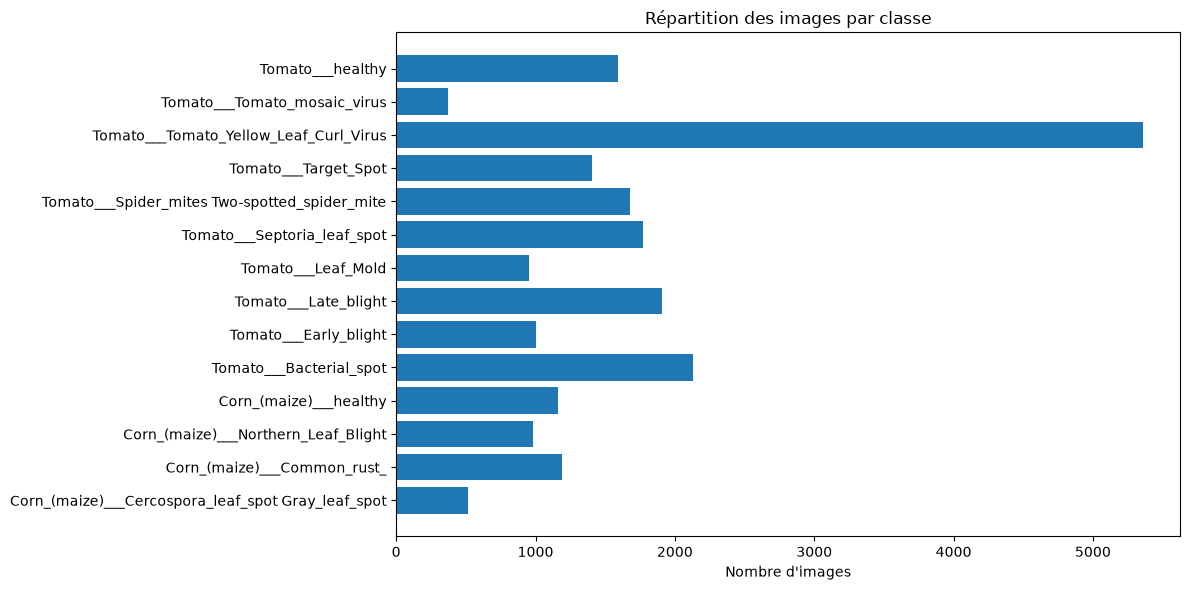

In [7]:
import matplotlib.pyplot as plt

counts = [
    len(list((DATA_DIR / classe).glob("*")))
    for classe in sorted(selected_classes)
]

plt.figure(figsize=(12, 6))
plt.barh(sorted(selected_classes), counts)
plt.xlabel("Nombre d'images")
plt.title("Répartition des images par classe")
plt.tight_layout()
plt.show()

In [8]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

print("Transformations prêtes.")

Transformations prêtes.


In [9]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

print("Nombre total d'images :", len(dataset))
print("Nombre de classes :", len(dataset.classes))

Nombre total d'images : 54305
Nombre de classes : 38


In [10]:
from torch.utils.data import Subset

selected_indices = [
    i for i, (_, label) in enumerate(dataset.samples)
    if dataset.classes[label] in selected_classes
]

filtered_dataset = Subset(dataset, selected_indices)

print("Nombre d'images filtrées :", len(filtered_dataset))

Nombre d'images filtrées : 22012


In [11]:
from torch.utils.data import random_split

train_size = int(0.8 * len(filtered_dataset))
test_size = len(filtered_dataset) - train_size

train_dataset, test_dataset = random_split(
    filtered_dataset,
    [train_size, test_size]
)

print("Images entraînement :", len(train_dataset))
print("Images test :", len(test_dataset))

Images entraînement : 17609
Images test : 4403


In [12]:
print("Classes :", dataset.classes)

print("\nNombre de classes sélectionnées :", len(selected_classes))
print("Images d'entraînement :", len(train_dataset))
print("Images de test :", len(test_dataset))

Classes : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato__

In [13]:
image, label = dataset[0]

print("Classe :", dataset.classes[label])
print("Taille :", image.shape)

Classe : Apple___Apple_scab
Taille : torch.Size([3, 224, 224])


In [14]:
image, label = filtered_dataset[0]

original_index = selected_indices[0]
original_label = dataset.samples[original_index][1]

print("Classe :", dataset.classes[original_label])
print("Taille :", image.shape)

Classe : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Taille : torch.Size([3, 224, 224])


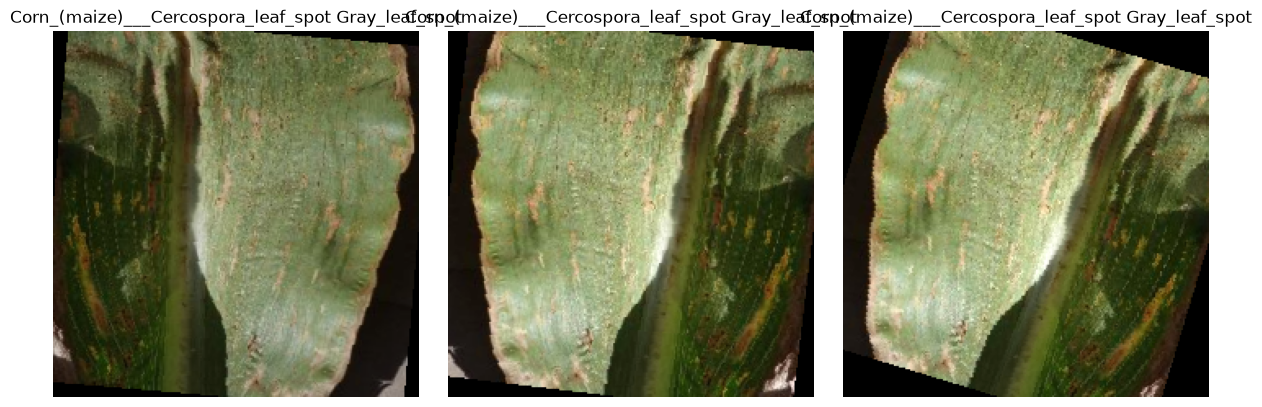

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    image, label = filtered_dataset[0]
    axes[i].imshow(image.permute(1, 2, 0))
    axes[i].set_title(dataset.classes[original_label])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [16]:
import torch
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset, random_split

# Dataset sans transformation
base_dataset = ImageFolder(
    root=DATA_DIR,
    transform=None
)

# Indices des 14 classes sélectionnées
filtered_indices = [
    i for i, (_, label) in enumerate(base_dataset.samples)
    if base_dataset.classes[label] in selected_classes
]

# Séparation reproductible 80/20
generator = torch.Generator().manual_seed(42)

train_indices, test_indices = random_split(
    filtered_indices,
    [17609, 4403],
    generator=generator
)

# Dataset d'entraînement avec augmentation
train_source = ImageFolder(
    root=DATA_DIR,
    transform=train_transform
)

# Dataset de test sans augmentation aléatoire
test_source = ImageFolder(
    root=DATA_DIR,
    transform=test_transform
)

train_dataset = Subset(train_source, list(train_indices))
test_dataset = Subset(test_source, list(test_indices))

print("Images entraînement :", len(train_dataset))
print("Images test :", len(test_dataset))

Images entraînement : 17609
Images test : 4403


In [17]:
train_image, train_label = train_dataset[0]
test_image, test_label = test_dataset[0]

print("Train :", train_image.shape)
print("Test  :", test_image.shape)

Train : torch.Size([3, 224, 224])
Test  : torch.Size([3, 224, 224])


In [18]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("DataLoaders créés.")
print("Nombre de batches train :", len(train_loader))
print("Nombre de batches test :", len(test_loader))

DataLoaders créés.
Nombre de batches train : 551
Nombre de batches test : 138


In [19]:
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/kaba/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 73.7MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Con

In [20]:
import torch.nn as nn

num_classes = len(selected_classes)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

print("Nombre de classes :", num_classes)
print("Nouvelle couche :", model.fc)

Nombre de classes : 14
Nouvelle couche : Linear(in_features=2048, out_features=14, bias=True)


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device utilisé :", device)

Device utilisé : cpu


In [23]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Fonction de perte :", criterion)
print("Optimiseur :", optimizer)

Fonction de perte : CrossEntropyLoss()
Optimiseur : Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


In [25]:
class_to_idx = {
    classe: idx
    for idx, classe in enumerate(sorted(selected_classes))
}

print("Mapping des classes :")
for classe, idx in class_to_idx.items():
    print(idx, "->", classe)

Mapping des classes :
0 -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
1 -> Corn_(maize)___Common_rust_
2 -> Corn_(maize)___Northern_Leaf_Blight
3 -> Corn_(maize)___healthy
4 -> Tomato___Bacterial_spot
5 -> Tomato___Early_blight
6 -> Tomato___Late_blight
7 -> Tomato___Leaf_Mold
8 -> Tomato___Septoria_leaf_spot
9 -> Tomato___Spider_mites Two-spotted_spider_mite
10 -> Tomato___Target_Spot
11 -> Tomato___Tomato_Yellow_Leaf_Curl_Virus
12 -> Tomato___Tomato_mosaic_virus
13 -> Tomato___healthy


In [26]:
class RemappedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, class_to_idx):
        self.dataset = dataset
        self.indices = indices
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, original_label = self.dataset[self.indices[idx]]

        original_class = self.dataset.classes[original_label]
        new_label = self.class_to_idx[original_class]

        return image, new_label


train_dataset = RemappedSubset(
    train_source,
    list(train_indices),
    class_to_idx
)

test_dataset = RemappedSubset(
    test_source,
    list(test_indices),
    class_to_idx
)

print("Train :", len(train_dataset))
print("Test  :", len(test_dataset))

Train : 17609
Test  : 4403


In [28]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("DataLoaders recréés.")

DataLoaders recréés.


In [29]:
images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)
loss = criterion(outputs, labels)

print("Images :", images.shape)
print("Labels :", labels.shape)
print("Sorties :", outputs.shape)
print("Loss :", loss.item())

Images : torch.Size([32, 3, 224, 224])
Labels : torch.Size([32])
Sorties : torch.Size([32, 14])
Loss : 2.629298448562622


In [30]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

print("Couches pré-entraînées gelées.")
print("Couche fc entraînable :", model.fc)

Couches pré-entraînées gelées.
Couche fc entraînable : Linear(in_features=2048, out_features=14, bias=True)


In [31]:
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.0001
)

print("Optimiseur configuré pour la couche fc.")

Optimiseur configuré pour la couche fc.


In [32]:
model.train()

running_loss = 0.0

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

epoch_loss = running_loss / len(train_loader)

print(f"Loss entraînement : {epoch_loss:.4f}")

Loss entraînement : 1.8250


In [33]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy test : {accuracy:.2f}%")

Accuracy test : 65.07%


In [34]:
torch.save(model.state_dict(), "resnet50_plantvillage_epoch1.pth")

print("Modèle sauvegardé.")

Modèle sauvegardé.


In [35]:
training_history = {
    "epoch": 1,
    "train_loss": 1.8250,
    "test_accuracy": 65.07
}

print(training_history)

{'epoch': 1, 'train_loss': 1.825, 'test_accuracy': 65.07}


In [36]:
# On garde les couches précédentes gelées
for param in model.parameters():
    param.requires_grad = False

# On déverrouille layer4 + la couche finale
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

# Vérification
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print("Paramètres entraînables :", trainable_params)
print("Paramètres totaux :", total_params)

Paramètres entraînables : 14993422
Paramètres totaux : 23536718


In [37]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.00001
)

print("Optimiseur reconfiguré.")
print("Learning rate :", optimizer.param_groups[0]["lr"])

Optimiseur reconfiguré.
Learning rate : 1e-05


In [38]:
print("layer4 entraînable :", any(p.requires_grad for p in model.layer4.parameters()))
print("fc entraînable :", any(p.requires_grad for p in model.fc.parameters()))
print("layer3 entraînable :", any(p.requires_grad for p in model.layer3.parameters()))

layer4 entraînable : True
fc entraînable : True
layer3 entraînable : False


In [39]:
model.train()

running_loss = 0.0

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

epoch_loss = running_loss / len(train_loader)

print(f"Loss entraînement : {epoch_loss:.4f}")

Loss entraînement : 0.7499


In [40]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy test : {accuracy:.2f}%")

Accuracy test : 88.62%


In [41]:
torch.save(model.state_dict(), "resnet50_plantvillage_epoch2.pth")

print("Modèle époque 2 sauvegardé.")

Modèle époque 2 sauvegardé.


In [42]:
model.train()

print("Modèle prêt pour l'époque 3.")

Modèle prêt pour l'époque 3.


In [43]:
running_loss = 0.0

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    running_loss += loss.item()

epoch_loss = running_loss / len(train_loader)

print(f"Loss entraînement : {epoch_loss:.4f}")

Loss entraînement : 0.3394


In [44]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy test : {accuracy:.2f}%")

Accuracy test : 94.71%


In [45]:
torch.save(model.state_dict(), "resnet50_plantvillage_epoch3.pth")

print("Modèle époque 3 sauvegardé.")

Modèle époque 3 sauvegardé.


In [46]:
from collections import defaultdict

model.eval()

correct_by_class = defaultdict(int)
total_by_class = defaultdict(int)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        for label, pred in zip(labels, predicted):
            label = label.item()
            pred = pred.item()

            total_by_class[label] += 1

            if label == pred:
                correct_by_class[label] += 1

print("Accuracy par classe :\n")

for class_name, class_idx in sorted(
    class_to_idx.items(),
    key=lambda x: x[1]
):
    accuracy_class = (
        100 * correct_by_class[class_idx] / total_by_class[class_idx]
    )

    print(f"{class_idx:2d} - {class_name}: {accuracy_class:.2f}%")

Accuracy par classe :

 0 - Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 85.39%
 1 - Corn_(maize)___Common_rust_: 99.14%
 2 - Corn_(maize)___Northern_Leaf_Blight: 86.93%
 3 - Corn_(maize)___healthy: 100.00%
 4 - Tomato___Bacterial_spot: 94.54%
 5 - Tomato___Early_blight: 68.56%
 6 - Tomato___Late_blight: 96.77%
 7 - Tomato___Leaf_Mold: 91.62%
 8 - Tomato___Septoria_leaf_spot: 93.62%
 9 - Tomato___Spider_mites Two-spotted_spider_mite: 97.38%
10 - Tomato___Target_Spot: 90.85%
11 - Tomato___Tomato_Yellow_Leaf_Curl_Virus: 99.73%
12 - Tomato___Tomato_mosaic_virus: 77.14%
13 - Tomato___healthy: 99.32%


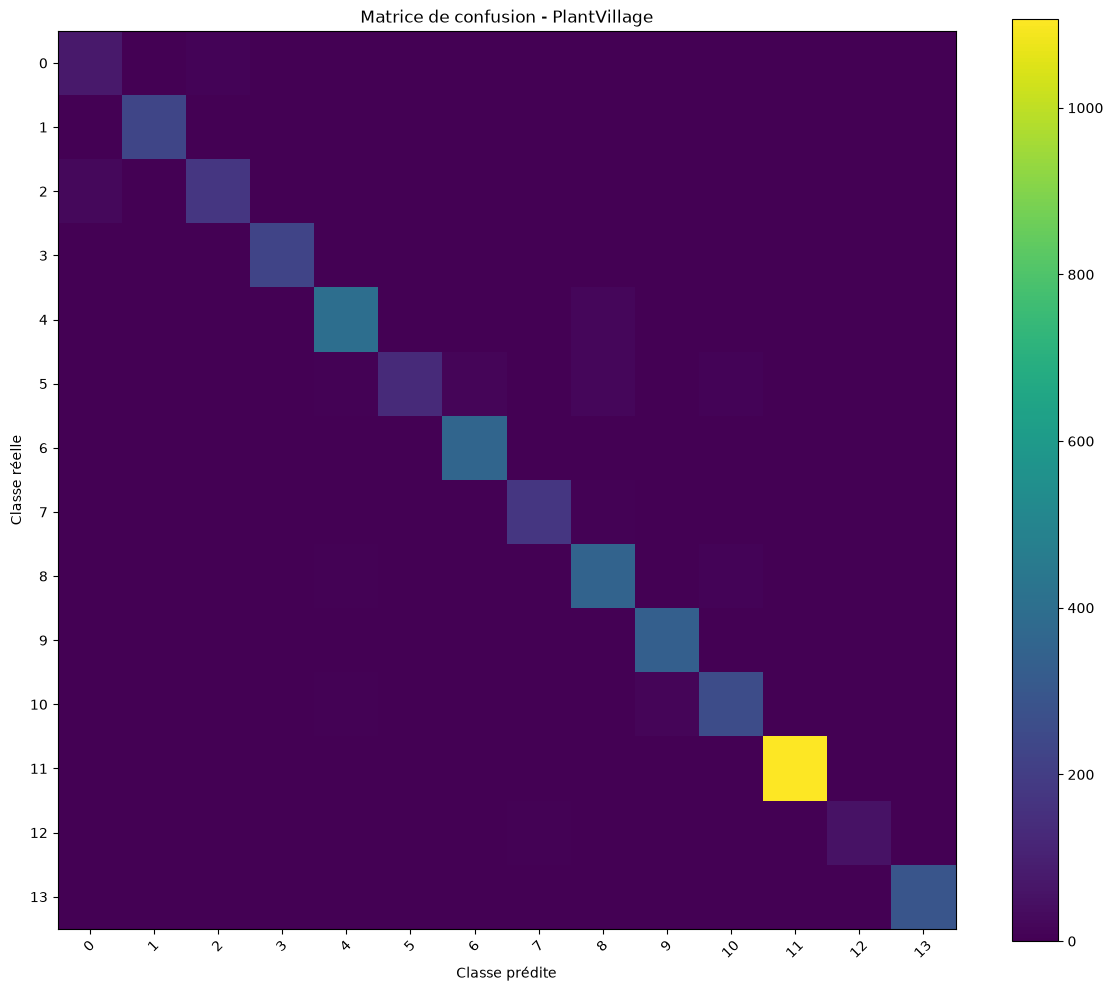

In [47]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predictions.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.colorbar()

plt.xticks(
    range(len(class_to_idx)),
    range(len(class_to_idx)),
    rotation=45
)

plt.yticks(
    range(len(class_to_idx)),
    range(len(class_to_idx))
)

plt.xlabel("Classe prédite")
plt.ylabel("Classe réelle")
plt.title("Matrice de confusion - PlantVillage")

plt.tight_layout()
plt.show()

In [48]:
from sklearn.metrics import f1_score

f1_macro = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

f1_weighted = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print(f"F1-score macro    : {f1_macro:.4f}")
print(f"F1-score weighted : {f1_weighted:.4f}")

F1-score macro    : 0.9220
F1-score weighted : 0.9461


In [49]:
print("Principales confusions :\n")

for i in range(len(class_to_idx)):
    for j in range(len(class_to_idx)):
        if i != j and cm[i, j] > 0:
            print(
                f"{i} -> {j} : {cm[i, j]} images"
            )

Principales confusions :

0 -> 1 : 1 images
0 -> 2 : 12 images
1 -> 2 : 2 images
2 -> 0 : 22 images
2 -> 1 : 3 images
2 -> 3 : 1 images
4 -> 6 : 1 images
4 -> 8 : 18 images
4 -> 11 : 4 images
5 -> 4 : 7 images
5 -> 6 : 16 images
5 -> 7 : 3 images
5 -> 8 : 20 images
5 -> 9 : 1 images
5 -> 10 : 11 images
5 -> 11 : 3 images
6 -> 4 : 1 images
6 -> 5 : 4 images
6 -> 7 : 1 images
6 -> 8 : 1 images
6 -> 9 : 1 images
6 -> 11 : 4 images
7 -> 4 : 1 images
7 -> 5 : 1 images
7 -> 6 : 1 images
7 -> 8 : 8 images
7 -> 9 : 2 images
7 -> 10 : 1 images
7 -> 11 : 2 images
8 -> 4 : 6 images
8 -> 5 : 4 images
8 -> 7 : 2 images
8 -> 9 : 1 images
8 -> 10 : 9 images
8 -> 11 : 1 images
8 -> 12 : 1 images
9 -> 4 : 1 images
9 -> 10 : 4 images
9 -> 11 : 1 images
9 -> 12 : 2 images
9 -> 13 : 1 images
10 -> 4 : 5 images
10 -> 5 : 1 images
10 -> 6 : 2 images
10 -> 8 : 2 images
10 -> 9 : 14 images
10 -> 11 : 1 images
10 -> 13 : 1 images
11 -> 4 : 1 images
11 -> 8 : 1 images
11 -> 10 : 1 images
12 -> 6 : 2 images
12 -

In [50]:
# Afficher les 15 principales confusions
confusions = []

for i in range(len(class_to_idx)):
    for j in range(len(class_to_idx)):
        if i != j and cm[i, j] > 0:
            confusions.append((
                cm[i, j],
                i,
                j
            ))

confusions = sorted(confusions, reverse=True)

print("Top 15 des confusions :\n")

for count, real_idx, predicted_idx in confusions[:15]:
    real_class = next(
        name for name, idx in class_to_idx.items()
        if idx == real_idx
    )
    predicted_class = next(
        name for name, idx in class_to_idx.items()
        if idx == predicted_idx
    )

    print(
        f"{count} images : "
        f"{real_class} -> {predicted_class}"
    )

Top 15 des confusions :

22 images : Corn_(maize)___Northern_Leaf_Blight -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
20 images : Tomato___Early_blight -> Tomato___Septoria_leaf_spot
18 images : Tomato___Bacterial_spot -> Tomato___Septoria_leaf_spot
16 images : Tomato___Early_blight -> Tomato___Late_blight
14 images : Tomato___Target_Spot -> Tomato___Spider_mites Two-spotted_spider_mite
12 images : Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot -> Corn_(maize)___Northern_Leaf_Blight
11 images : Tomato___Early_blight -> Tomato___Target_Spot
9 images : Tomato___Septoria_leaf_spot -> Tomato___Target_Spot
8 images : Tomato___Leaf_Mold -> Tomato___Septoria_leaf_spot
7 images : Tomato___Early_blight -> Tomato___Bacterial_spot
6 images : Tomato___Septoria_leaf_spot -> Tomato___Bacterial_spot
5 images : Tomato___Tomato_mosaic_virus -> Tomato___Leaf_Mold
5 images : Tomato___Target_Spot -> Tomato___Bacterial_spot
4 images : Tomato___Spider_mites Two-spotted_spider_mite -> Tomato___T